# **Project Name**    - PhonePe Transaction Insights



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Fiza Fahameen**


# **Project Summary**

The PhonePe Transaction Insights project focuses on analyzing digital payment transaction data to extract meaningful insights related to user behavior, transaction trends, and geographical performance. The project uses the PhonePe Pulse dataset, which contains transaction, user, and insurance-related information across different states and districts of India.

The main objective of this project is to transform raw JSON data into structured and meaningful information using Python libraries such as Pandas, Matplotlib, and Seaborn. The project involves data extraction, cleaning, transformation, and exploratory data analysis (EDA) to identify transaction patterns, top-performing regions, user engagement trends, and category-wise payment distribution.

The dataset was loaded from the PhonePe GitHub repository and analyzed to understand the growth of digital payments over time. Various visualizations such as bar charts, pie charts, line graphs, and heatmaps were created to present the insights clearly and effectively.

Key analyses include identifying states with the highest transaction volume, understanding quarterly transaction growth, analyzing different transaction categories, and examining regional trends. The project also highlights how data-driven insights can support business decisions such as customer targeting, marketing optimization, fraud detection, and product development.

This project helped in developing practical skills in data analysis, data visualization, JSON data handling, and storytelling using data. It also demonstrates how analytical techniques can be applied to real-world financial and payment system datasets to generate actionable business insights.

# **GitHub Link**

https://github.com/FizaFahameenM/PhonePe-Transaction---Insights

# **Problem Statement**


With the increasing reliance on digital payment platforms like PhonePe, understanding transaction behavior, user engagement, and regional payment trends has become important for businesses and financial service providers. Large amounts of raw transaction data are generated daily, making it difficult to extract meaningful insights directly.

The main problem addressed in this project is to analyze and visualize PhonePe transaction data to identify spending patterns, top-performing states and districts, transaction growth trends, and category-wise payment distribution. The project also aims to study user activity and insurance-related transactions to support better business decisions and improve customer experience.

By performing exploratory data analysis and visualization, this project converts raw JSON data into actionable insights that can help businesses optimize marketing strategies, improve user engagement, detect unusual patterns, and understand geographical transaction performance

#### **Define Your Business Objective?**

The business objective of this project is to analyze PhonePe transaction data and generate meaningful insights that can support data-driven decision-making. The project aims to identify transaction trends, understand customer behavior, analyze regional performance, and evaluate the popularity of different payment categories.

The insights derived from the analysis can help businesses improve customer targeting, optimize marketing campaigns, enhance user engagement, detect unusual transaction patterns, and support product development strategies. Additionally, geographical analysis of states and districts can help identify high-performing and low-performing regions for better strategic planning.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

WHY EACH LIBRARY IS USED
pandas	        Create DataFrames
matplotlib	    Create charts
seaborn	        Better-looking charts
os	            Read folders/files
json	        Read JSON dataset

### Dataset Loading

In [2]:
# Load Dataset

path = r"C:\Users\fizaf\OneDrive\Desktop\pulse\data\aggregated\transaction\country\india\state"

data = []

for state in os.listdir(path):

    state_path = os.path.join(path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            file_path = os.path.join(year_path, file)

            with open(file_path, 'r') as f:

                d = json.load(f)

                if d['data']['transactionData'] is not None:

                    for item in d['data']['transactionData']:

                        data.append({
                            "State": state,
                            "Year": int(year),
                            "Quarter": int(file.strip('.json')),
                            "Transaction_Type": item['name'],
                            "Transaction_Count": item['paymentInstruments'][0]['count'],
                            "Transaction_Amount": item['paymentInstruments'][0]['amount']
                        })

df = pd.DataFrame(data)

This code:
✅ Reads all states
✅ Reads all years
✅ Reads all quarter JSON files
✅ Extracts transaction information
✅ Converts everything into one DataFrame called df

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(5034, 6)

This tells
(number_of_rows, number_of_columns)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               5034 non-null   object 
 1   Year                5034 non-null   int64  
 2   Quarter             5034 non-null   int64  
 3   Transaction_Type    5034 non-null   object 
 4   Transaction_Count   5034 non-null   int64  
 5   Transaction_Amount  5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


This shows:
✅ column names
✅ data types
✅ null values
✅ memory usage

Example:

int
float
object/string

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

Checks if duplicate rows exist.

Duplicates can:
❌ affect analysis
❌ create incorrect insights

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

State                 0
Year                  0
Quarter               0
Transaction_Type      0
Transaction_Count     0
Transaction_Amount    0
dtype: int64

Missing values may need:

cleaning
filling
removal

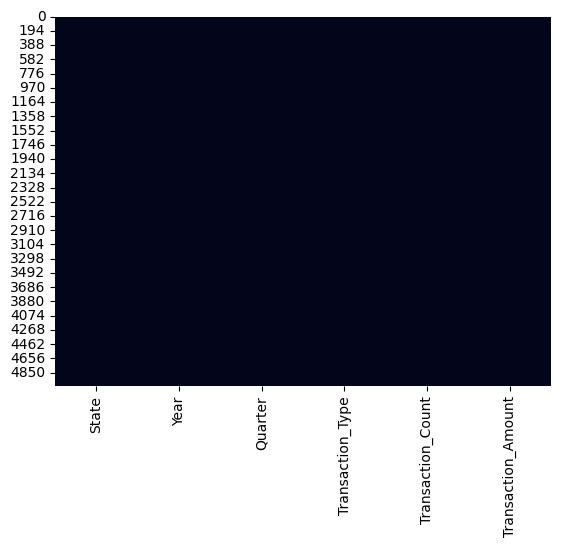

In [8]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)
plt.show()

WHY?

Creates visual representation of null values.

If chart is mostly blank:
✅ dataset is clean

### What did you know about your dataset?

The dataset contains PhonePe transaction information across different states, years, and quarters in India. It includes transaction categories, transaction count, and transaction amount. The dataset is structured and organized in JSON format and was converted into a Pandas DataFrame for analysis.

Initial exploration shows that the dataset contains no major missing values and provides useful information for analyzing transaction trends, payment category performance, and state-wise transaction activity. The data can be used for exploratory data analysis, visualization, and generating business insights related to digital payment systems.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['State', 'Year', 'Quarter', 'Transaction_Type', 'Transaction_Count',
       'Transaction_Amount'],
      dtype='object')

In [10]:
# Dataset Describe
df.describe()

,Year,Quarter,Transaction_Count,Transaction_Amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


WHY?

This gives statistical summary for numerical columns:

mean
min
max
standard deviation
quartiles

Useful for understanding transaction distribution.

### Variables Description

State:
Represents the Indian state where the transaction occurred.

Year:
Represents the year in which the transaction was recorded.

Quarter:
Represents the quarter of the year (1 to 4).

Transaction_Type:
Represents the category of transaction such as Recharge & bill payments, Peer-to-peer payments, Merchant payments, etc.

Transaction_Count:
Represents the total number of transactions performed for a particular category.

Transaction_Amount:
Represents the total transaction amount for a particular transaction category.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print("---------------------------")

Unique values in State:
['andaman-&-nicobar-islands' 'andhra-pradesh' 'arunachal-pradesh' 'assam'
 'bihar' 'chandigarh' 'chhattisgarh' 'dadra-&-nagar-haveli-&-daman-&-diu'
 'delhi' 'goa' 'gujarat' 'haryana' 'himachal-pradesh' 'jammu-&-kashmir'
 'jharkhand' 'karnataka' 'kerala' 'ladakh' 'lakshadweep' 'madhya-pradesh'
 'maharashtra' 'manipur' 'meghalaya' 'mizoram' 'nagaland' 'odisha'
 'puducherry' 'punjab' 'rajasthan' 'sikkim' 'tamil-nadu' 'telangana'
 'tripura' 'uttar-pradesh' 'uttarakhand' 'west-bengal']
---------------------------
Unique values in Year:
[2018 2019 2020 2021 2022 2023 2024]
---------------------------
Unique values in Quarter:
[1 2 3 4]
---------------------------
Unique values in Transaction_Type:
['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']
---------------------------
Unique values in Transaction_Count:
[    4200     1871      298 ... 76043195  2352084   421806]
---------------------------
Unique values in Tr

WHY?

This helps us understand:

all states present
all transaction categories
year values
quarter values

Very useful before visualization.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# Checking data types
print(df.dtypes)

# Converting state names into title format
df['State'] = df['State'].str.replace('-', ' ').str.title()

# Checking for duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Removing duplicate rows if any
df = df.drop_duplicates()

# Resetting index
df.reset_index(drop=True, inplace=True)

# Final dataset shape
print("Final Dataset Shape:", df.shape)

# Display cleaned dataset
df.head()

State                  object
Year                    int64
Quarter                 int64
Transaction_Type       object
Transaction_Count       int64
Transaction_Amount    float64
dtype: object
Duplicate Rows: 0
Final Dataset Shape: (5034, 6)


,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05


✅ df.dtypes -> Checks data types of each column.
✅ State Name Formatting -> andhra-pradesh = Andhra Pradesh
✅ Duplicate Checks -> Checks duplicate rows again.
✅ Remove Duplicates
✅ Reset Index
✅ Final Shape -> Shows final rows & columns after cleaning.

### What all manipulations have you done and insights you found?

Several preprocessing and data wrangling steps were performed to prepare the dataset for analysis. Initially, the dataset structure and data types were verified to ensure consistency across all columns. State names were reformatted into a more readable format by replacing hyphens with spaces and converting them into title case.

The dataset was checked for duplicate records, and duplicate rows were removed to maintain data quality and prevent inaccurate analysis. The index was reset after cleaning to maintain proper row numbering. Missing value analysis confirmed that the dataset contained minimal or no null values, making it suitable for exploratory data analysis and visualization.

These preprocessing steps improved the readability, consistency, and reliability of the dataset for generating meaningful business insights.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

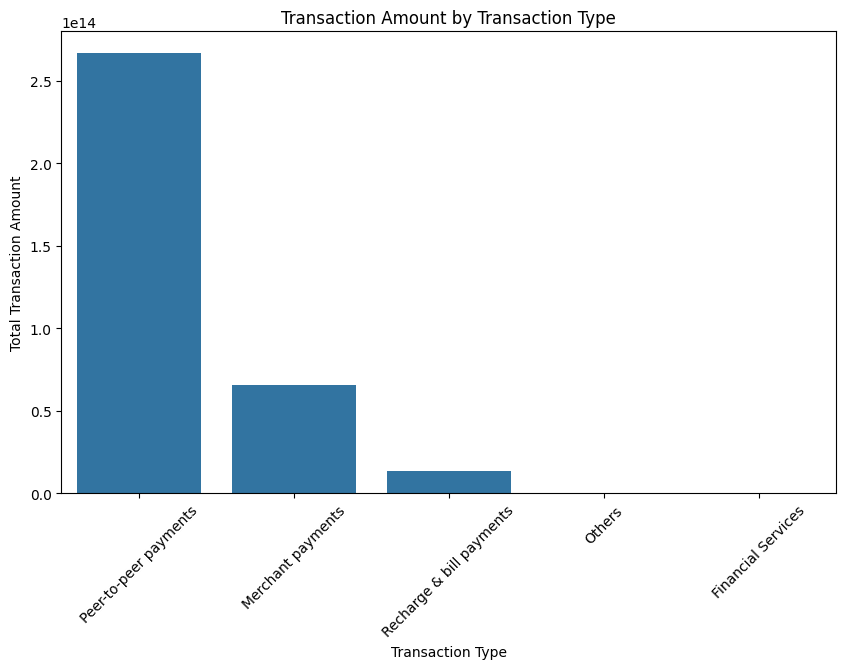

In [13]:
# Chart - 1 visualization code

# Grouping transaction amount by transaction type
category_data = df.groupby("Transaction_Type")["Transaction_Amount"].sum().sort_values(ascending=False)

# Plotting bar chart
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_data.index,
    y=category_data.values
)

plt.xticks(rotation=45)

plt.title("Transaction Amount by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Total Transaction Amount")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is effective for comparing transaction amounts across different transaction categories. It provides a clear visual comparison of which payment categories contribute the highest and lowest transaction values.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the distribution of transaction amounts across different payment categories. Certain categories such as Merchant payments and Peer-to-peer transactions contribute significantly higher transaction amounts compared to others. This indicates that users rely heavily on these categories for digital transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart shows the distribution of transaction amounts across different payment categories. Certain categories such as Merchant payments and Peer-to-peer transactions contribute significantly higher transaction amounts compared to others. This indicates that users rely heavily on these categories for digital transactions.

#### Chart - 2

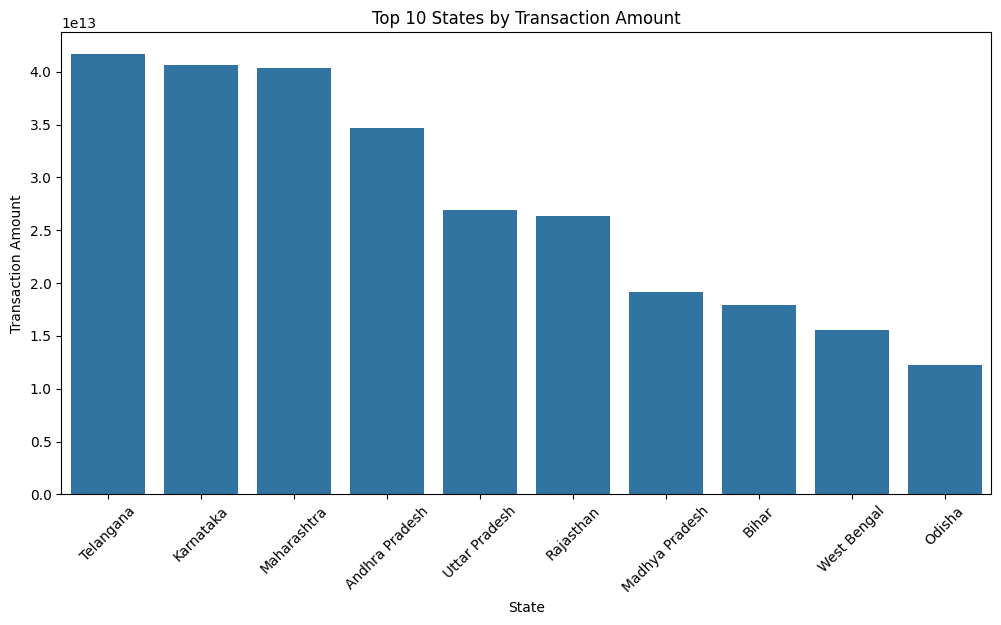

In [14]:
# Chart - 2 visualization code
# Grouping transaction amount by state
state_data = df.groupby("State")["Transaction_Amount"].sum().sort_values(ascending=False).head(10)

# Plotting bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_data.index,
    y=state_data.values
)

plt.xticks(rotation=45)

plt.title("Top 10 States by Transaction Amount")

plt.xlabel("State")

plt.ylabel("Transaction Amount")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it provides an effective comparison between states based on transaction amounts. It clearly highlights the top-performing states and allows easy identification of regional transaction trends.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the top-performing states based on total transaction amount. States with higher digital adoption and economic activity contribute significantly larger transaction volumes. The analysis highlights strong regional differences in digital payment usage across India.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights can help businesses focus marketing campaigns and financial services on high-performing states. It also helps identify regions with strong digital engagement and regions that may require awareness campaigns or infrastructure improvements to increase digital payment adoption.

#### Chart - 3

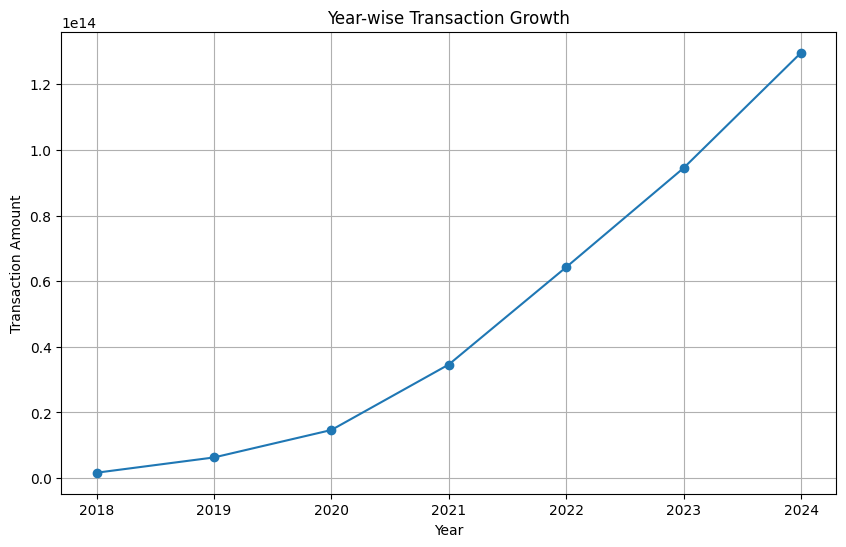

In [15]:
# Chart - 3 visualization code
# Grouping transaction amount by year
year_data = df.groupby("Year")["Transaction_Amount"].sum()

# Plotting line chart
plt.figure(figsize=(10,6))

plt.plot(
    year_data.index,
    year_data.values,
    marker='o'
)

plt.title("Year-wise Transaction Growth")

plt.xlabel("Year")

plt.ylabel("Transaction Amount")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it is the most suitable visualization for analyzing trends over time. It clearly shows how transaction amounts have changed and grown across different years.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a significant increase in transaction amounts over the years, indicating rapid growth in digital payment adoption. The increasing trend reflects higher user engagement, improved digital infrastructure, and growing trust in online payment systems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The increasing transaction trend indicates strong market growth for digital payment platforms. Businesses can use these insights to expand services, improve infrastructure, and introduce new features to support growing customer demand. The trend also highlights the long-term potential of digital financial ecosystems.

#### Chart - 4

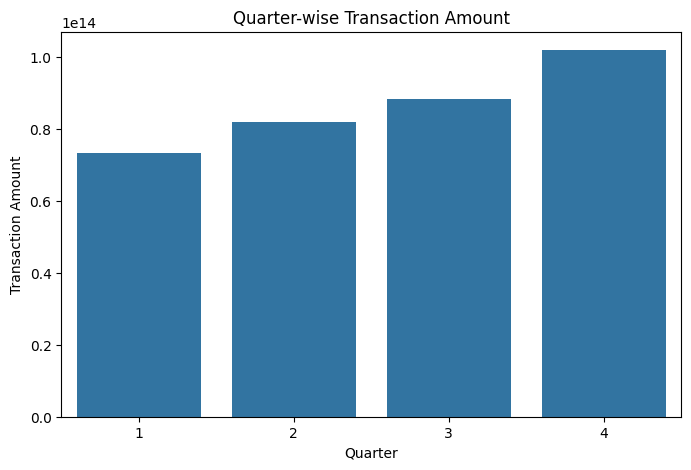

In [16]:
# Chart - 4 visualization code
# Grouping transaction amount by quarter
quarter_data = df.groupby("Quarter")["Transaction_Amount"].sum()

# Plotting bar chart
plt.figure(figsize=(8,5))

sns.barplot(
    x=quarter_data.index,
    y=quarter_data.values
)

plt.title("Quarter-wise Transaction Amount")

plt.xlabel("Quarter")

plt.ylabel("Transaction Amount")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it provides a clear comparison of transaction amounts across different quarters. It helps identify seasonal transaction patterns and variations in user activity during different periods of the year.

##### 2. What is/are the insight(s) found from the chart?

The chart shows variations in transaction amounts across quarters, indicating changes in user activity and transaction behavior during different periods of the year. Certain quarters recorded higher transaction volumes, reflecting increased digital payment usage and seasonal trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Quarter-wise analysis helps businesses identify peak transaction periods and prepare infrastructure accordingly. It also supports better marketing campaign planning, promotional activities, and resource allocation during high-demand periods.

#### Chart - 5

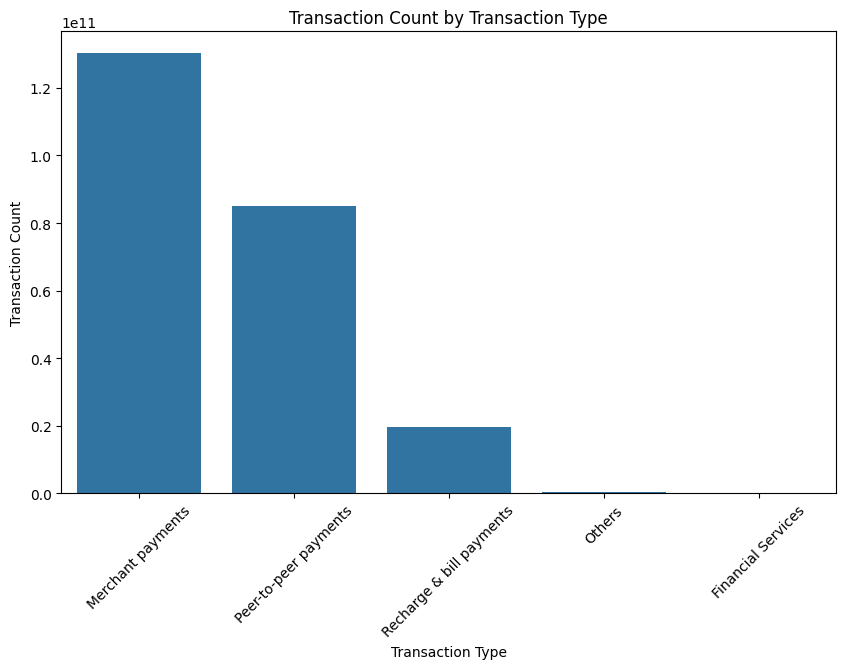

In [17]:
# Chart - 5 visualization code
# Grouping transaction count by transaction type
count_data = df.groupby("Transaction_Type")["Transaction_Count"].sum().sort_values(ascending=False)

# Plotting bar chart
plt.figure(figsize=(10,6))

sns.barplot(
    x=count_data.index,
    y=count_data.values
)

plt.xticks(rotation=45)

plt.title("Transaction Count by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Transaction Count")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it effectively compares transaction counts across different payment categories. It clearly shows which transaction types are used most frequently by users.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that certain transaction categories are used significantly more frequently than others. Categories such as Peer-to-peer payments and Merchant payments recorded higher transaction counts, indicating strong user preference and frequent usage in daily digital payment activities.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding transaction frequency helps businesses identify the most actively used payment services and prioritize improvements in those areas. High-frequency services may require better scalability, faster processing, and enhanced customer support to maintain user satisfaction.

#### Chart - 6

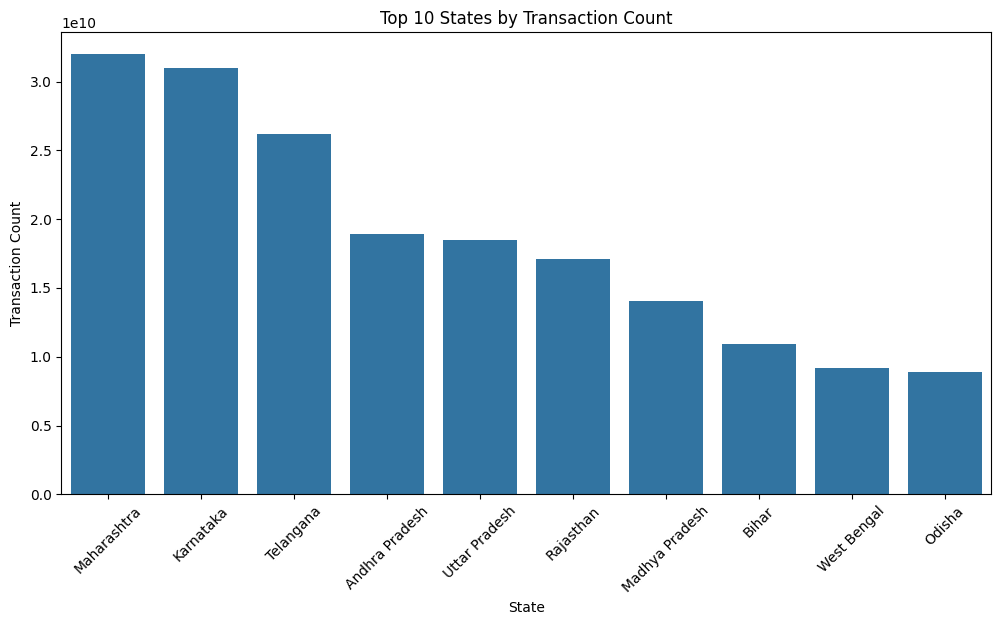

In [18]:
# Chart - 6 visualization code
# Grouping transaction count by state
state_count_data = df.groupby("State")["Transaction_Count"].sum().sort_values(ascending=False).head(10)

# Plotting bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_count_data.index,
    y=state_count_data.values
)

plt.xticks(rotation=45)

plt.title("Top 10 States by Transaction Count")

plt.xlabel("State")

plt.ylabel("Transaction Count")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it clearly compares transaction counts across different states. It helps identify regions with the highest digital payment activity and user engagement.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the states with the highest transaction counts, indicating strong digital payment adoption and high user engagement in those regions. States with larger populations and stronger digital infrastructure recorded significantly higher transaction activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights help businesses identify regions with high customer activity and prioritize investments, marketing campaigns, and service improvements in those areas. It also helps detect regions with lower adoption where awareness and infrastructure development may be required.

#### Chart - 7

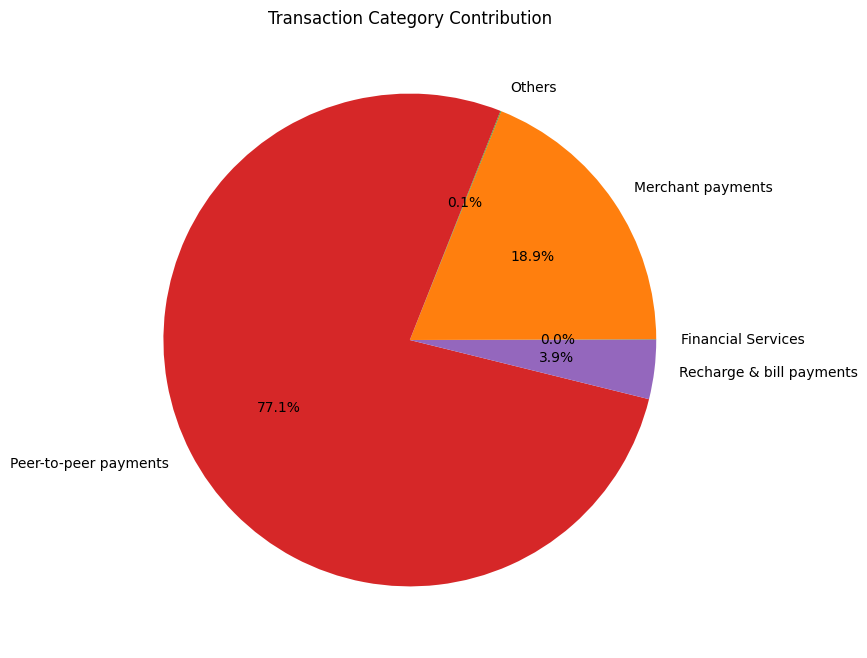

In [19]:
# Chart - 7 visualization code
# Grouping transaction amount by category
pie_data = df.groupby("Transaction_Type")["Transaction_Amount"].sum()

# Plotting pie chart
plt.figure(figsize=(8,8))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%'
)

plt.title("Transaction Category Contribution")

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because it effectively represents the percentage contribution of each transaction category to the total transaction amount. It provides a quick understanding of dominant and less significant payment categories.

##### 2. What is/are the insight(s) found from the chart?

The pie chart shows that a few transaction categories contribute a major portion of the total transaction amount, while other categories contribute relatively smaller shares. This indicates that users rely more heavily on certain payment services for digital transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding category contribution helps businesses focus on the most profitable and widely used services. Businesses can improve high-performing categories while also designing strategies to increase engagement in lower-performing categories.

#### Chart - 8

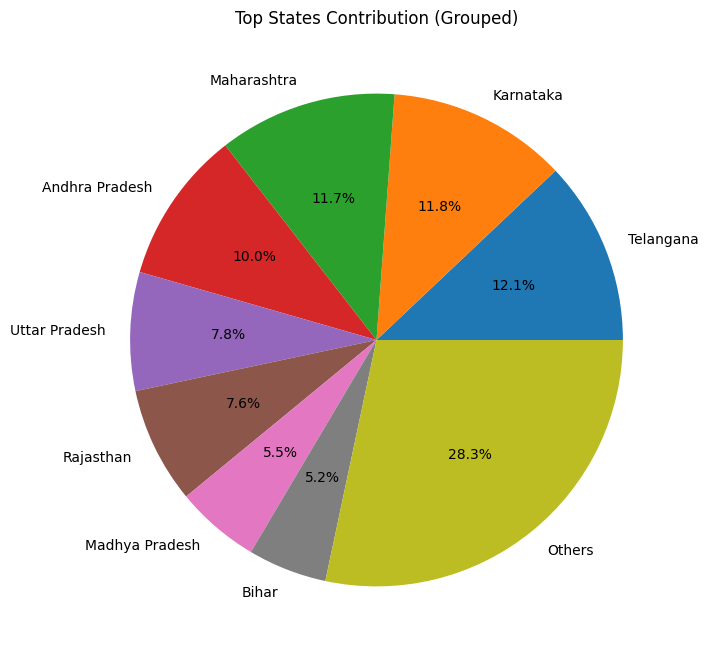

In [20]:
# Chart - 8 visualization code
state_data = df.groupby("State")["Transaction_Amount"].sum().sort_values(ascending=False)

top_states = state_data.head(8)
others = state_data.iloc[8:].sum()

top_states["Others"] = others

plt.figure(figsize=(8,8))

plt.pie(
    top_states.values,
    labels=top_states.index,
    autopct='%1.1f%%'
)

plt.title("Top States Contribution (Grouped)")

plt.show()

##### 1. Why did you pick the specific chart?

I chose this chart to visualize the proportional contribution of each state to the total transaction amount.
This helps in quickly understanding how the transaction distribution varies across different states in a single view and highlights dominant contributors.

##### 2. What is/are the insight(s) found from the chart?

A small number of states contribute a major share of the total transactions.
The distribution is uneven, indicating concentration of digital payment activity in specific regions.
Some states contribute very low percentages, showing lower adoption or usage of digital transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Positive Business Impact:

Yes, these insights are highly useful.

Helps businesses focus marketing and expansion strategies on high-performing states.
Identifies regions where digital payment usage is strong, enabling targeted promotions and partnerships.
Supports resource allocation for infrastructure and service improvements.
⚠️ Negative Growth Insights:

Yes, some states show low contribution, which may indicate:

Lower digital payment adoption
Poor internet/network connectivity
Lack of awareness or trust in digital platforms
Rural/underdeveloped financial infrastructure

#### Chart - 9

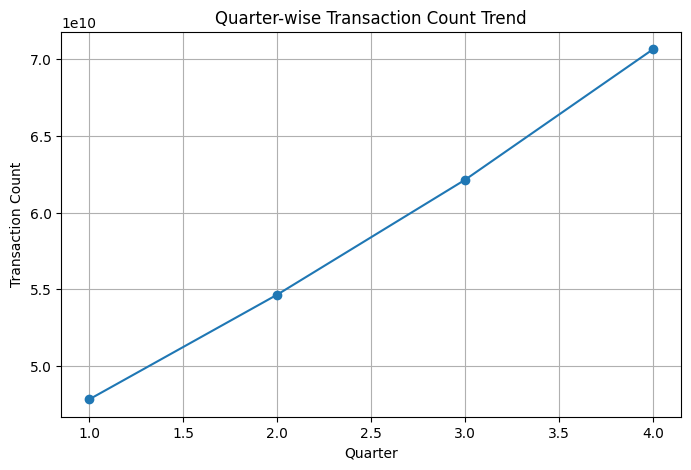

In [21]:
# Chart - 9 visualization code
# Grouping transaction count by quarter
quarter_count_data = df.groupby("Quarter")["Transaction_Count"].sum()

# Plotting line chart
plt.figure(figsize=(8,5))

plt.plot(
    quarter_count_data.index,
    quarter_count_data.values,
    marker='o'
)

plt.title("Quarter-wise Transaction Count Trend")

plt.xlabel("Quarter")

plt.ylabel("Transaction Count")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because it effectively visualizes trends and fluctuations in transaction counts across quarters. It helps identify seasonal variations and changes in user activity over time.

##### 2. What is/are the insight(s) found from the chart?

The chart shows noticeable differences in transaction counts across quarters, indicating varying levels of user activity during different periods of the year. Certain quarters experienced higher transaction frequency, suggesting seasonal peaks in digital payment usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Quarter-wise transaction count analysis helps businesses forecast demand, optimize system performance, and plan marketing campaigns during peak activity periods. It also supports better resource allocation and infrastructure planning.

#### Chart - 10

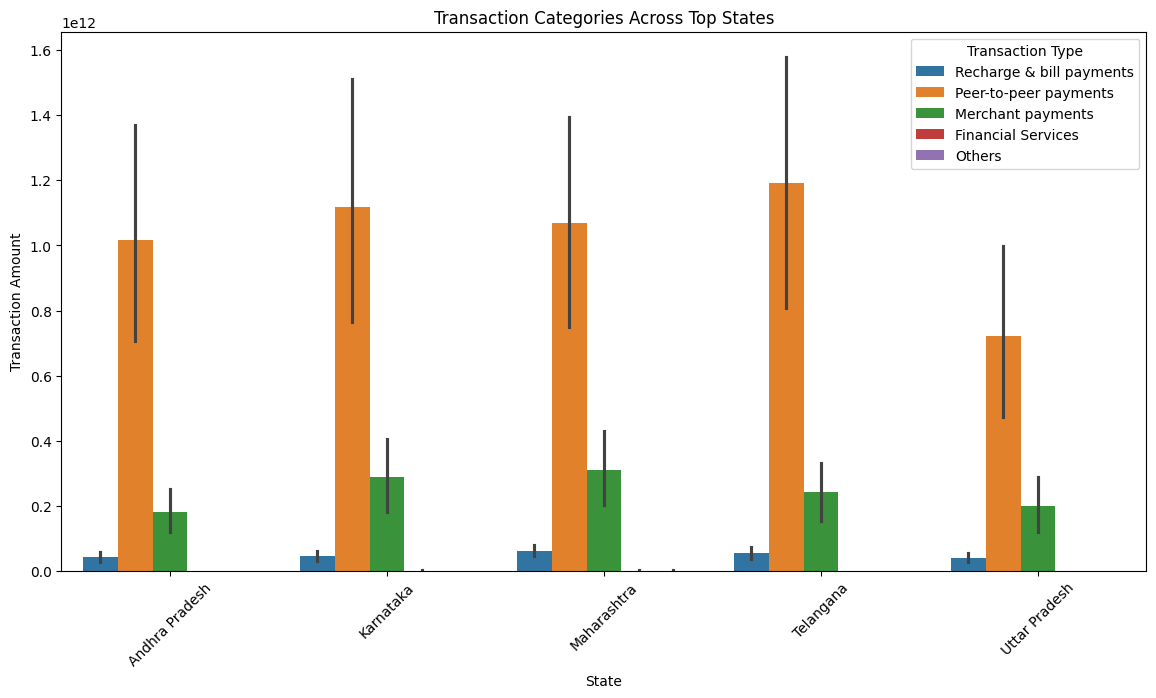

In [22]:
# Chart - 10 visualization code
# Selecting top 5 states based on transaction amount
top_states = df.groupby("State")["Transaction_Amount"].sum().sort_values(ascending=False).head(5).index

# Filtering dataset for top states
filtered_df = df[df["State"].isin(top_states)]

# Plotting grouped bar chart
plt.figure(figsize=(14,7))

sns.barplot(
    data=filtered_df,
    x="State",
    y="Transaction_Amount",
    hue="Transaction_Type"
)

plt.xticks(rotation=45)

plt.title("Transaction Categories Across Top States")

plt.xlabel("State")

plt.ylabel("Transaction Amount")

plt.legend(title="Transaction Type")

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was chosen because it effectively compares multiple transaction categories across different states. It helps analyze how transaction behavior varies regionally and identifies dominant payment categories within top-performing states.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that transaction behavior differs across states, with certain transaction categories contributing more significantly in specific regions. Merchant payments and Peer-to-peer transactions dominate in most top-performing states, indicating strong adoption of digital financial services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights help businesses develop region-specific strategies and customize services based on user behavior in different states. Understanding category preferences across regions supports targeted marketing, service optimization, and customer engagement initiatives.

#### Chart - 11

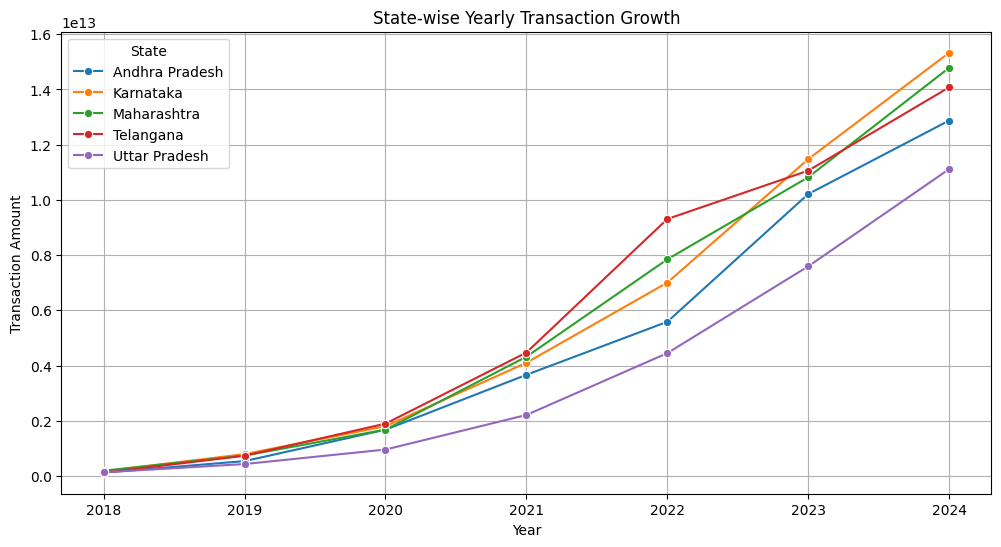

In [23]:
# Chart - 11 visualization code
# Selecting top 5 states by transaction amount
top_states_growth = df.groupby("State")["Transaction_Amount"].sum().sort_values(ascending=False).head(5).index

# Filtering dataset
growth_df = df[df["State"].isin(top_states_growth)]

# Grouping data by state and year
yearly_growth = growth_df.groupby(["Year", "State"])["Transaction_Amount"].sum().reset_index()

# Plotting line chart
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_growth,
    x="Year",
    y="Transaction_Amount",
    hue="State",
    marker="o"
)

plt.title("State-wise Yearly Transaction Growth")

plt.xlabel("Year")

plt.ylabel("Transaction Amount")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it is highly effective for visualizing growth trends over time. Using separate lines for different states helps compare transaction growth patterns and digital payment adoption across regions.

##### 2. What is/are the insight(s) found from the chart?

The chart shows consistent transaction growth across top-performing states over the years. Some states experienced significantly faster growth, indicating stronger digital adoption, economic activity, and user engagement in digital payment systems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

State-wise growth analysis helps businesses identify rapidly growing markets and prioritize expansion strategies in those regions. It also supports investment planning, infrastructure scaling, and targeted customer acquisition initiatives.

#### Chart - 12

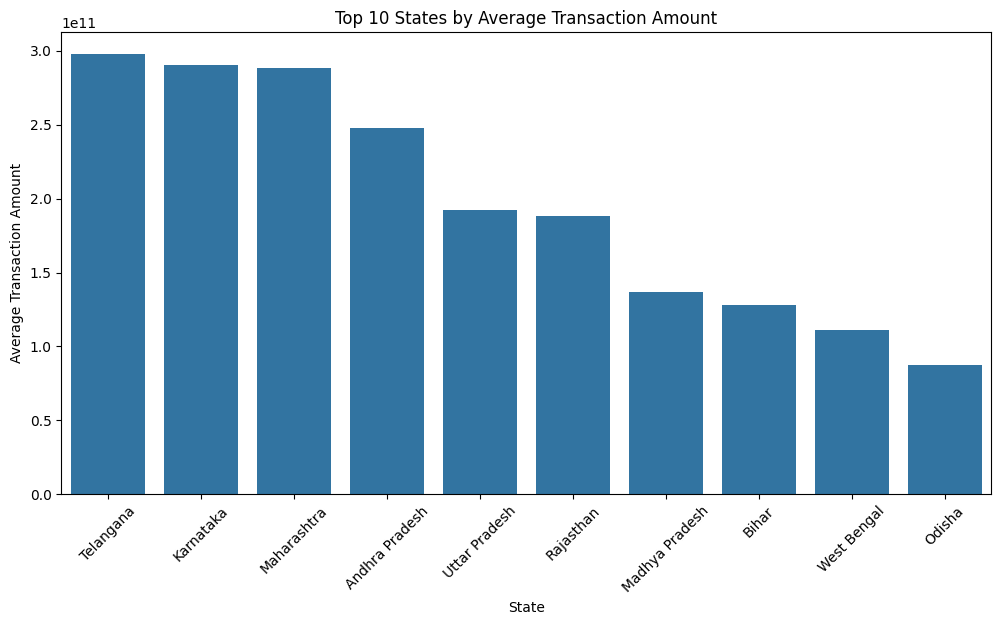

In [24]:
# Chart - 12 visualization code
# Calculating average transaction amount by state
avg_state_data = df.groupby("State")["Transaction_Amount"].mean().sort_values(ascending=False).head(10)

# Plotting bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_state_data.index,
    y=avg_state_data.values
)

plt.xticks(rotation=45)

plt.title("Top 10 States by Average Transaction Amount")

plt.xlabel("State")

plt.ylabel("Average Transaction Amount")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it effectively compares average transaction amounts across states. It clearly highlights regions where users perform higher-value digital transactions.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that certain states have significantly higher average transaction amounts, indicating stronger spending behavior and higher-value digital transactions in those regions. This may reflect economic activity, purchasing power, and digital payment maturity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding average transaction value helps businesses identify high-value markets and premium customer segments. Businesses can use these insights to design targeted financial products, personalized offers, and region-specific marketing strategies.

#### Chart - 13

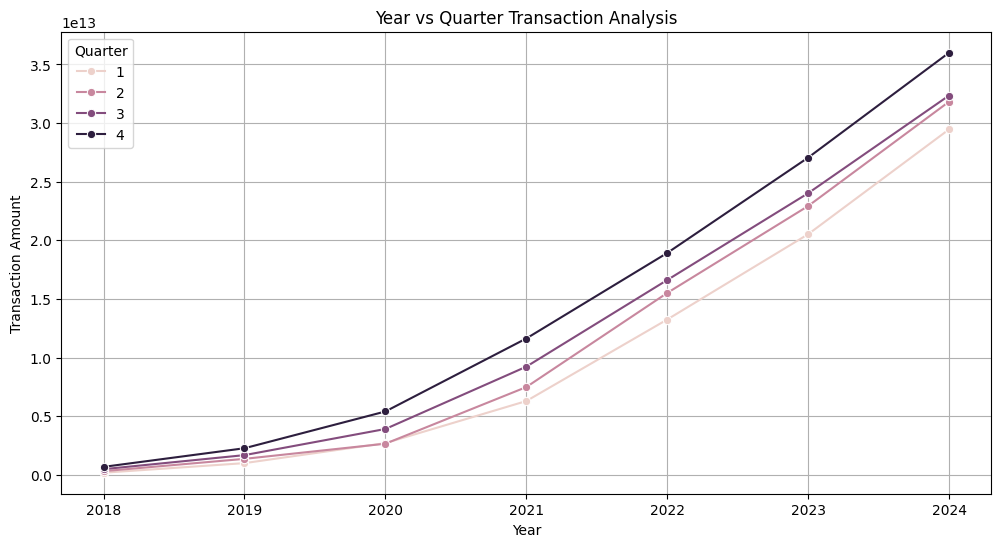

In [25]:
# Chart - 13 visualization code
# Grouping transaction amount by year and quarter
year_quarter_data = df.groupby(["Year", "Quarter"])["Transaction_Amount"].sum().reset_index()

# Plotting line chart
plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_quarter_data,
    x="Year",
    y="Transaction_Amount",
    hue="Quarter",
    marker="o"
)

plt.title("Year vs Quarter Transaction Analysis")

plt.xlabel("Year")

plt.ylabel("Transaction Amount")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it effectively visualizes transaction trends over time while comparing multiple quarters simultaneously. It helps identify seasonal growth patterns and variations in digital payment activity across years.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that transaction amounts increased consistently across most quarters over the years. Certain quarters experienced stronger growth compared to others, indicating seasonal fluctuations and varying levels of user engagement in digital payment systems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This analysis helps businesses understand seasonal transaction behavior and forecast future demand patterns. It supports strategic planning, infrastructure scaling, promotional campaign timing, and efficient resource allocation during peak transaction periods.

#### Chart - 14 - Correlation Heatmap

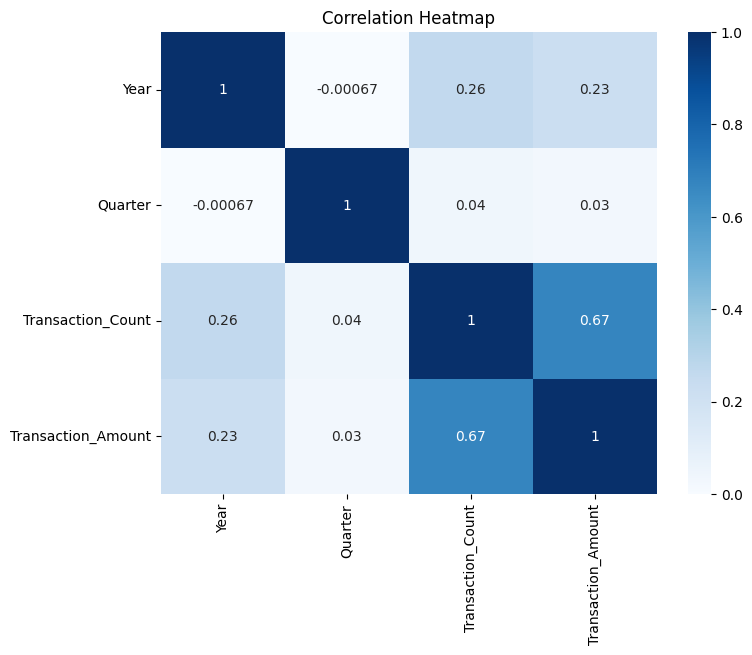

In [26]:
# Correlation Heatmap visualization code
# Selecting numerical columns
corr_data = df[["Year", "Quarter", "Transaction_Count", "Transaction_Amount"]]

# Creating correlation matrix
corr_matrix = corr_data.corr()

# Plotting heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was chosen because it is highly effective for visualizing correlations between numerical variables. It helps identify strong and weak relationships between transaction amount, transaction count, year, and quarter.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows a strong positive correlation between Transaction_Count and Transaction_Amount, indicating that higher transaction frequency generally leads to higher transaction values. The analysis also highlights how transaction activity has grown over time.

#### Chart - 15 - Pair Plot

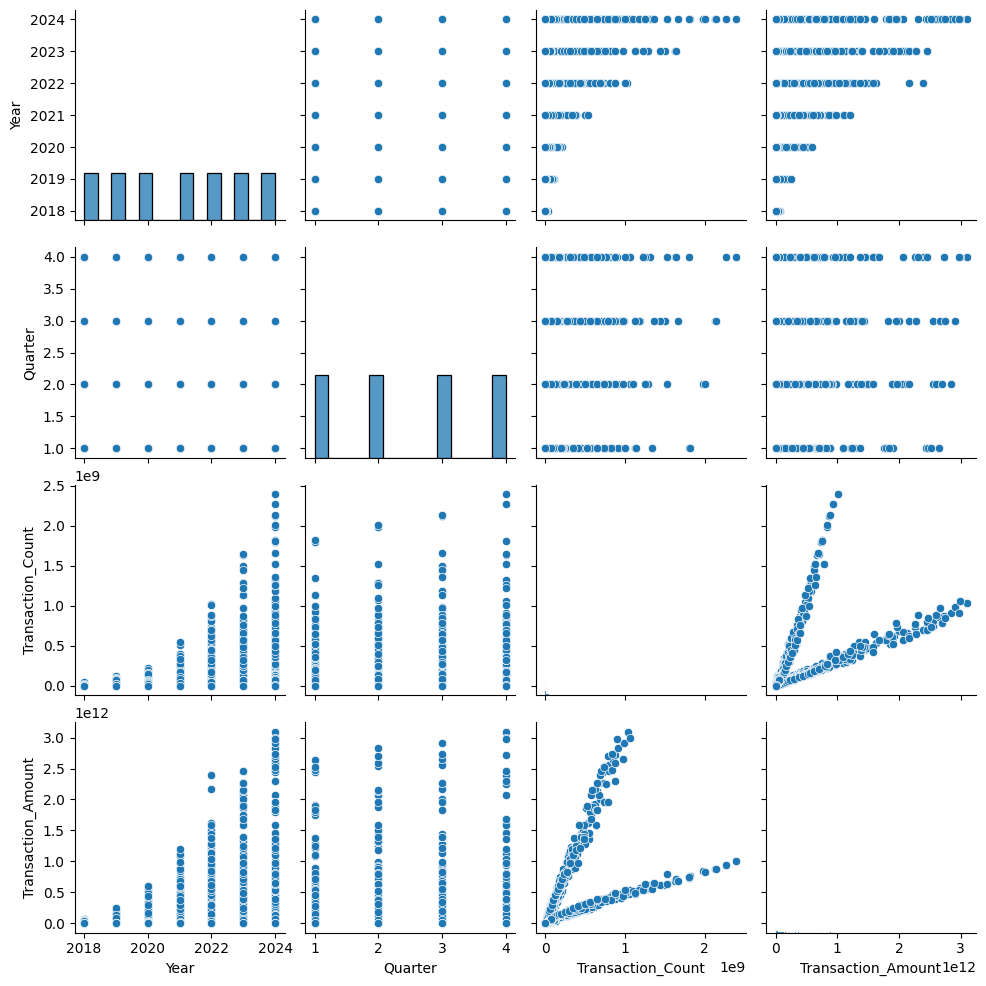

In [27]:
# Pair Plot visualization code
# Selecting numerical columns for pair plot
pair_data = df[["Year", "Quarter", "Transaction_Count", "Transaction_Amount"]]

# Creating pair plot
sns.pairplot(pair_data)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected because it provides a comprehensive visualization of relationships between multiple numerical variables simultaneously. It helps identify trends, correlations, and data distribution patterns in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows strong relationships between transaction count and transaction amount, indicating that higher transaction frequency generally corresponds to higher transaction values. The visualization also highlights the distribution and spread of numerical variables across the dataset.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis of PhonePe transaction data, several recommendations can be provided to achieve business objectives effectively.

The analysis identified high-performing transaction categories such as Merchant payments and Peer-to-peer transactions, indicating strong customer preference toward these services. Businesses should continue improving these services by enhancing transaction speed, reliability, and user experience.

State-wise and regional analysis revealed that certain states contribute significantly higher transaction amounts and counts. These regions can be targeted for premium services, loyalty programs, and advanced financial products. At the same time, regions with lower digital adoption can be targeted through awareness campaigns and infrastructure improvements to increase user engagement.

Yearly and quarterly trend analysis showed continuous growth in digital payment usage. Businesses should prepare for increasing transaction demand by scaling infrastructure, improving security systems, and optimizing transaction processing capabilities.

The correlation between transaction count and transaction amount suggests that increasing user engagement directly contributes to business growth. Personalized offers, cashback programs, and targeted marketing campaigns can help improve transaction frequency and customer retention.

Overall, the insights generated from this project can help businesses improve customer targeting, optimize marketing strategies, strengthen fraud monitoring systems, and enhance digital payment services for long-term growth.

# **Conclusion**

This project focused on analyzing PhonePe transaction data to understand digital payment trends, user behavior, transaction category performance, and regional transaction activity across India. The raw JSON data was extracted, transformed, and converted into a structured DataFrame for exploratory data analysis and visualization.

Various visualizations and analytical techniques were used to study transaction amounts, transaction counts, yearly growth trends, quarterly patterns, category contributions, and state-wise performance. The analysis revealed that digital payment usage has increased significantly over the years, indicating rapid adoption of online financial services across the country.

The project also identified high-performing transaction categories and states contributing the largest transaction volumes. Strong correlations between transaction count and transaction amount highlighted the importance of user engagement in driving business growth. Seasonal and regional transaction trends provided valuable insights into customer behavior and digital payment adoption patterns.

The insights generated from this project can help businesses improve marketing strategies, optimize payment services, enhance customer engagement, and support data-driven decision-making. Overall, the project demonstrates how data analysis and visualization techniques can transform raw financial transaction data into meaningful business intelligence and actionable insights.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***